## Дисклеймер!!!!!

Поскольку я терпеть ненавижу отвратно структурированный код, я большую часть инжиринга признаков вынес в отдельный файл. Направление действий будет видно как и указано в задании, но сразу для всего. Я не писал всё одним батчем, тут положена куча коммитов, просто для сохранения ясности я решил не сваливать всё в одну нечитабельную кучу. 

По поводу баллов - претендую на баллы за каждый из указанныз в ДЗ пунктов кроме топ-3 (пока что)

## Грузим данные

Из основных фич которые я выделил за это время:

1) Количество добавлений в корзину/поисков/просмотров
2) "Вероятность" добавления в корзину при наличии клика по товару
3) Статистики по количествуй действий за каждую сессию (40 минут)
4) Последние 3/2/1 действия(е)
5) TFIDF + SVD по тексту поиска
6) Флаги на запросы по самым популярным продуктам питания
7) Количество уникальных запросов
8) Статистики по длине запроса в словах/символях (медианная, максимальная, средняя)
9) Последний запрос, его длина в символах и словах
10) Средняя/максимальная/минимальная цена просмотренного товара
11) Доля товаров купленных по скидке
12) Среднее значение скидки
13) Доля наиболее частой категории товаров

+ все признаки которые были в преложенном решении

Скор - 0.81949

### UPD
Добавил в `embedding_features` колонку-список эмбеддингов поиска TFIDF+SVD, результат только ухудшился (примерно на 0.002)

### UPD 2
Добавил ещё кучу признаков:

14)  Динамика активности
- Количество действий за последние 7/30 дней и за предыдущие периоды (предыдущие 7 и 30 дней)
- Отдельно считаются: клики, добавления в корзину, заказы, поиски, уникальные товары
- Разности между окнами (например: actions_last_7d - actions_prev_7d)
- Отношения между окнами (например: (actions_last_7d + 1) / (actions_prev_7d + 1))
- Аналогичные признаки для кликов, корзины, заказов и поисков

15)  Конверсия поиска в действия
- Количество переходов:
  - search → click в течение 5 / 30 / 60 минут
  - search → to_cart в течение 5 / 30 / 60 минут
- Среднее время от поиска до клика
- Среднее время от поиска до добавления в корзину
- Нормированные коэффициенты:
  - search_to_click_rate
  - search_to_cart_rate

16)  Признаки по виджетам
- Общее количество действий через виджеты
- Количество уникальных виджетов
- Самый частый виджет (favorite_widget)
- Последний использованный виджет
- Доля действий из самого частого виджета (favorite_widget_share)
- Энтропия распределения по виджетам
- Доли действий в топ-K наиболее популярных виджетах

17)  Повторяемость и лояльность
- Количество уникальных товаров, категорий, брендов
- Количество повторных взаимодействий (один и тот же объект более одного раза)
- Доля повторных товаров 
- Доля повторных категорий
- Доля повторных брендов
- Доля наиболее популярного товара/категории/бренда
- Повторяемость отдельно для действий:
  - click
  - to_cart
  - order

Скор - 0.81987

In [1]:
from sklearnex import patch_sklearn 

patch_sklearn()

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


In [2]:
from data_preparation import OzonDataFormer
from datetime import date
import pandas as pd

In [3]:
data_params = {
    'include_actions': True,
    'include_search': True,
    'include_price': True,
    # UPD
    'group_embedding': False,
    # UPD 2
    'include_trend': True,
    'include_action_conversion': True,
    'include_repeat_loyalty': True,
    'include_widget': False,
}

In [4]:
do_construct = False

In [5]:
if do_construct:
    former = OzonDataFormer()
    former.fit_text_vectorizer(feature_end_date=date(2024, 5, 31))
    train_df = former.construct_dataset(
        feature_end_date=date(2024, 5, 31),
        target_start_date=date(2024, 6, 1),
        target_end_date=date(2024, 6, 30),
        **data_params
    )
    val_df = former.construct_dataset(
        feature_end_date=date(2024, 6, 30),
        target_start_date=date(2024, 7, 1),
        target_end_date=date(2024, 7, 31),
        **data_params
    )
    train_df.to_parquet('data/train.parquet',
                        index=False, engine='fastparquet')
    val_df.to_parquet('data/val.parquet',
                      index=False, engine='fastparquet')
else:
    train_df = pd.read_parquet('data/train.parquet', engine='fastparquet')
    val_df = pd.read_parquet('data/val.parquet', engine='fastparquet')

In [6]:
X_train = train_df.drop(columns=['user_id', 'target'])
y_train = train_df['target']

In [7]:
X_val = val_df.drop(columns=['user_id', 'target'])
y_val = val_df['target']

Удаляем лишние признаки (объяснение дальше)

In [8]:
import json

with open('drop.json', encoding='utf-8-sig') as f:
    drop_features = json.load(f)

In [9]:
drop_features = set([*drop_features['constant_features'], *[second for first, second in drop_features['duplicate_features']], *drop_features['high_corr_drop_candidates']])

In [10]:
from utils2 import AutoFeatureStandardizer

In [11]:
standardizer = AutoFeatureStandardizer(to_drop=drop_features)

In [12]:
X_train = standardizer.fit_transform(X_train)

/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:2054: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_out[f"{col}_is_nan"] = np.isnan(x).astype(float)
/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:2054: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_out[f"{col}_is_nan"] = np.isnan(x).astype(float)
/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:2054: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at on

In [13]:
X_val = standardizer.transform(X_val)

/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:2054: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_out[f"{col}_is_nan"] = np.isnan(x).astype(float)
/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:2054: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_out[f"{col}_is_nan"] = np.isnan(x).astype(float)
/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:2054: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at on

In [14]:
import gc

gc.collect()
del train_df
del val_df

## Проверка адекватности разделения на тренировку и валидацию

In [15]:
import numpy as np

In [16]:
cat_features = list(X_train.select_dtypes('category').columns)

In [17]:
embedding_features = ['search_emb'] if 'search_emb' in X_train.columns else None

In [18]:
from catboost.utils import get_gpu_device_count

if get_gpu_device_count() > 0:
    task_type = 'GPU'
else:
    task_type = 'CPU'

params = {
    'iterations': 100,
    'depth': 7,
    'random_state': 1,
    'eval_metric': 'AUC',
    'loss_function': 'Logloss',
    'auto_class_weights': 'Balanced',
    'task_type': task_type,
    'cat_features': cat_features,
    'embedding_features': embedding_features,
    'devices': '0'
}

# search_tfidfsvd

In [19]:
from validation_check import get_train_val_difference

# diff_score, _, _ = get_train_val_difference(X_train, y_train, X_val, y_val, params)

In [20]:
# diff_score

Скор получился примерно 0.78. Ну выглядит вроде адекватно учитывая что в данных очевидно есть временная зависимость

### UPD
Периодически при добавлении новых признаков скор менялся от 0.7 до 0.85. Всё ещё норм, опять же дрифт временных данных тут играет свою роль.

## Обучение модели

In [21]:
from catboost import CatBoostClassifier, Pool

In [22]:
train_pool = Pool(
    X_train,
    label=y_train,
    cat_features=params.get('cat_features'),
    embedding_features=params.get('embedding_features'),
    thread_count=4
)

val_pool = Pool(
    X_val,
    label=y_val,
    cat_features=params.get('cat_features'),
    embedding_features=params.get('embedding_features'),
    thread_count=4
)

In [23]:
params['iterations'] = 5000

model = CatBoostClassifier(**params)

In [24]:
model_name = "models/idklol.bin"

try:
    model.load_model(model_name)
except Exception:
    model.fit(
        train_pool,
        eval_set=val_pool,
        use_best_model=True,
        verbose=10,
        early_stopping_rounds=50,
    )
    model.save_model(model_name)

### UPD

Добавим обучение LightGBM-модели для сравнения

In [25]:
import lightgbm as lgb

In [26]:
lgb_params = {
    "objective": "binary",
    "metric": "auc",
    "boosting_type": "gbdt",

    "learning_rate": 0.05,
    "max_depth": 6,
    "num_leaves": 31,

    "lambda_l2": 10.0,
    "lambda_l1": 0.0,

    "bagging_fraction": 0.8,
    "bagging_freq": 1,
    "feature_fraction": 1.0,

    "min_data_in_leaf": 100,
    "min_gain_to_split": 0.0,

    "verbosity": -1,
}

In [27]:
train_dataset = lgb.Dataset(X_train, label=y_train)
val_dataset = lgb.Dataset(X_val, label=y_val)

In [28]:
lgb_model = lgb.train(
    lgb_params,
    train_set=train_dataset,
    valid_sets=[train_dataset, val_dataset],
    valid_names=["train", "valid"],
    num_boost_round=4000,
    callbacks=[
        lgb.early_stopping(stopping_rounds=200),
        lgb.log_evaluation(period=100),
    ],
)

Training until validation scores don't improve for 200 rounds
[100]	train's auc: 0.751338	valid's auc: 0.755387
[200]	train's auc: 0.753353	valid's auc: 0.756389
[300]	train's auc: 0.754568	valid's auc: 0.756807
[400]	train's auc: 0.755616	valid's auc: 0.757021
[500]	train's auc: 0.756465	valid's auc: 0.757096
[600]	train's auc: 0.757236	valid's auc: 0.757193
[700]	train's auc: 0.757992	valid's auc: 0.757128
[800]	train's auc: 0.75864	valid's auc: 0.75719
Early stopping, best iteration is:
[624]	train's auc: 0.757464	valid's auc: 0.757236


## Интерпретация модели

In [ ]:
from utils2 import AutoFeatureStandardizer, BinaryClassifierInterpreter
from cluster_compare import NotebookBinaryClusterInterpreter
from bokeh.io import output_notebook

In [ ]:
import panel as pn
pn.extension()

In [ ]:
output_notebook()

tool = NotebookBinaryClusterInterpreter(
    X=X_train.loc[::30],
    y=y_train.loc[::30],
)
tool.show()

Loading BokehJS ...

/home/i3alumba/Projects/AI/aim_ml/.venv/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/home/i3alumba/Projects/AI/aim_ml/.venv/lib/python3.13/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


BokehModel(combine_events=True, render_bundle={'docs_json': {'053f4829-4f15-418f-909a-a9049d8c50c1': {'version…

А выглядит интересно, чётко видны 2 кластера, надо посмотреть чё там такое.

### UPD
Я добавил соотношение меток классов к кластерам, получается интересная картина. В левом кластере оба класса представлены $\pm$ одинаково, а во втором соотношение примерно 50/50. Мб имеет смысл использовать результаты кластеризации как признаки для модели, но надо хорошо подумать над алгоритмом кластеризации

### UPD 2
Я добавил SHAP, к сожалению никаких особых откровений. По большому счёту - разделение пользователей по активности.

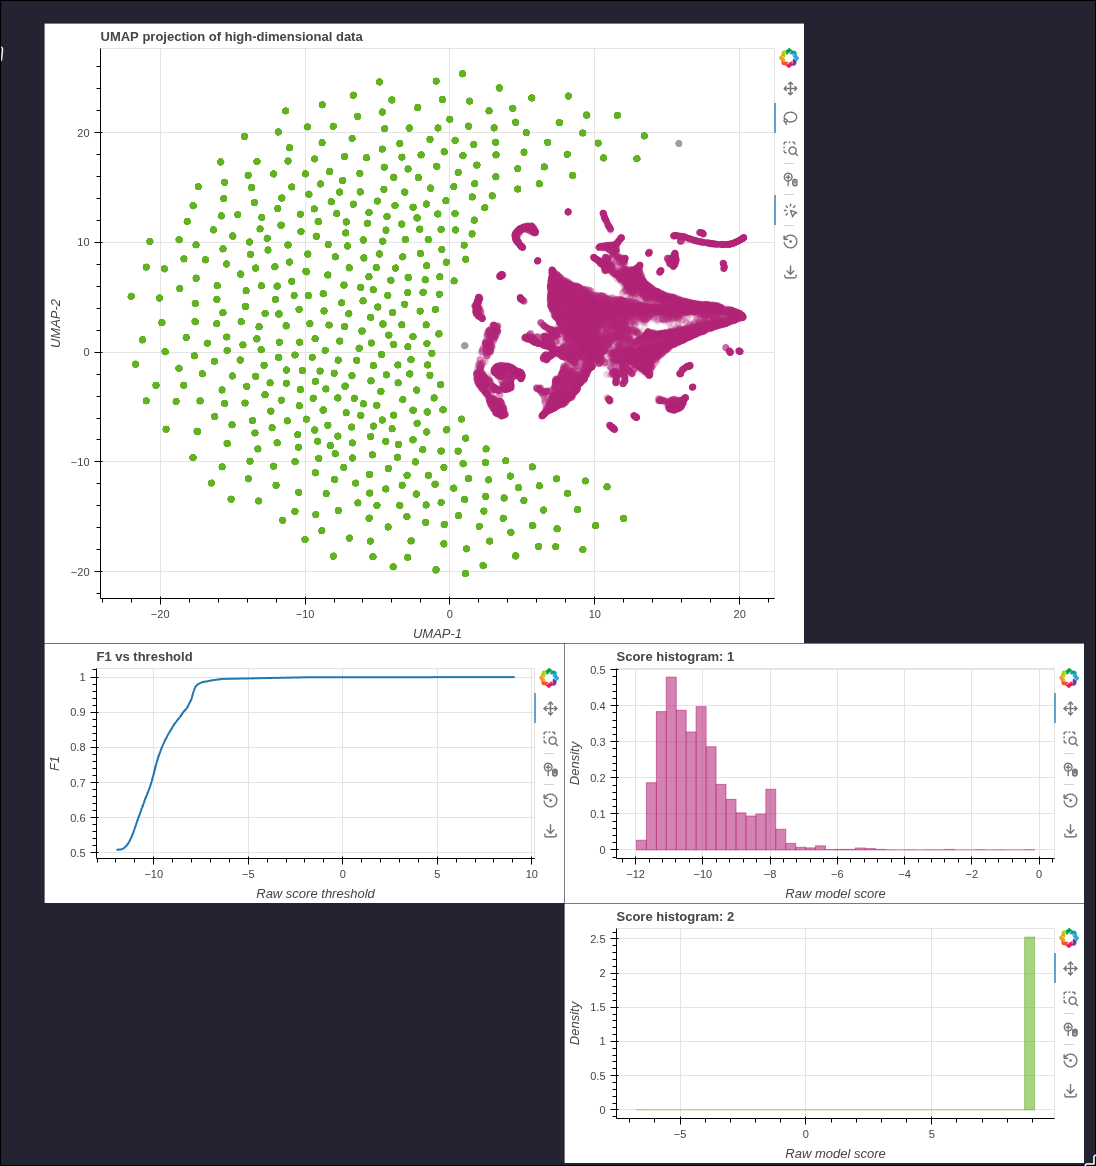

In [ ]:
interpreter = BinaryClassifierInterpreter(
    train=(X_train[::30], y_train[::30]),
    val=(X_val[::10], y_val[::10]),
    model=model
)

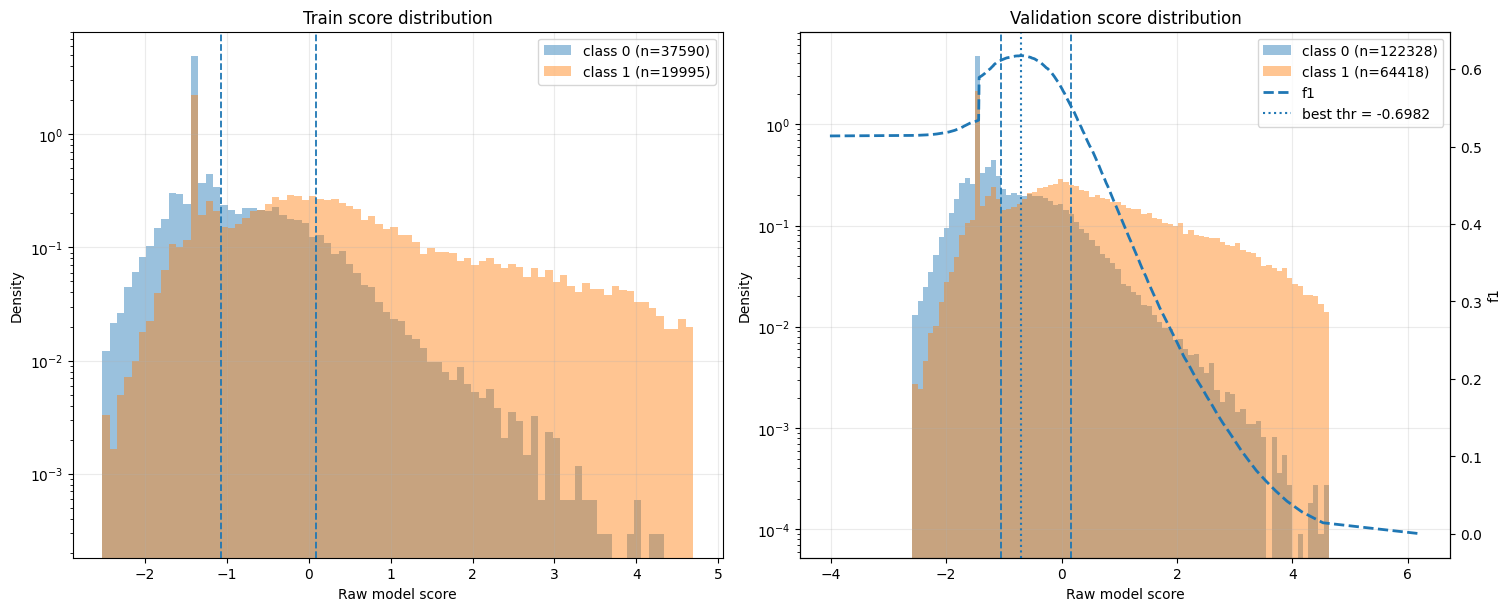

In [ ]:
interpreter.plot_score_histograms_with_val_metric(val_metric_name="f1", use_log_density_y=True);

In [ ]:
interpreter.plot_float_feature_histograms()

In [ ]:
interpreter.plot_score_feature_contours()

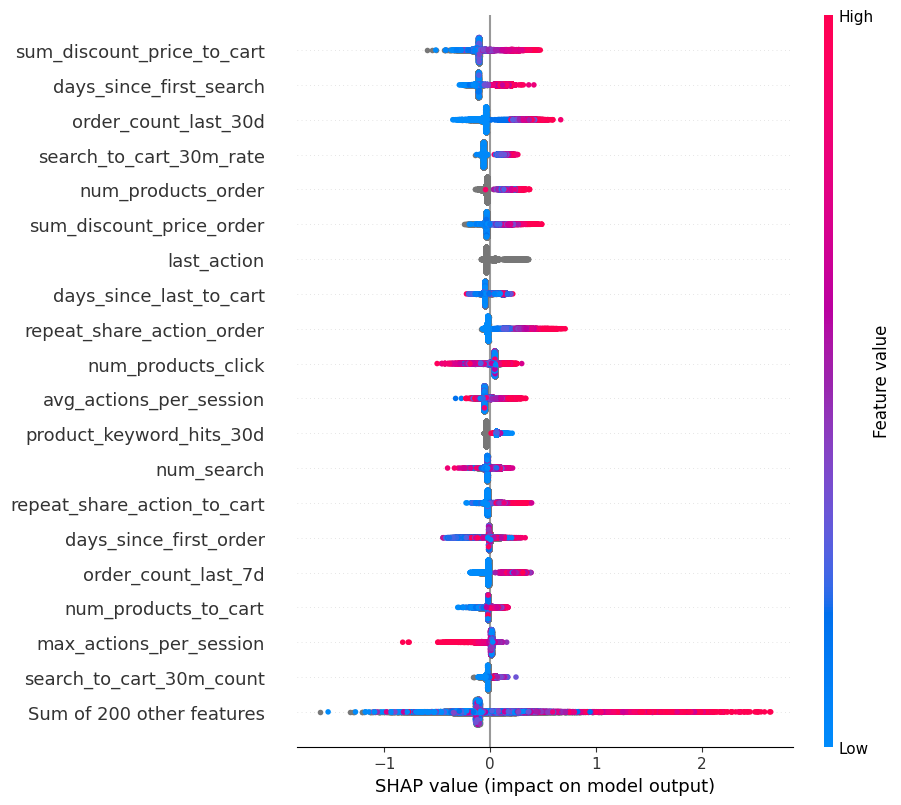

In [ ]:
interpreter.plot_shap_beeswarm(sample_frac=0.1);

Ну в целом видно что обычно у нас есть не какой-то железобетонный признак а просто мелкие улики того что юзер более склонен к одной из вещей, причём зачастую обратное неверно (ну то есть например если за последние 30 дней мало заказов то это значит что он вряд ли что-то закажет, но наоборот это не работает, ещё хороший пример - max_actions_per_session)

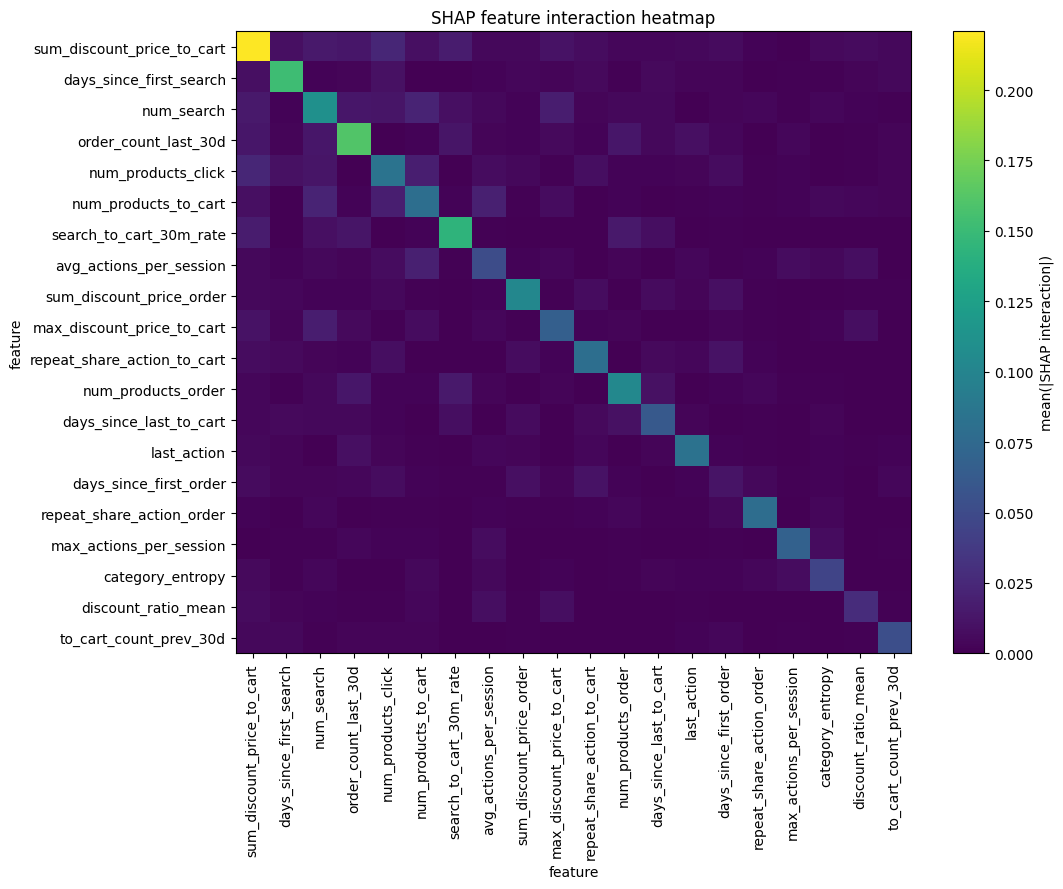

In [ ]:
interpreter.plot_shap_interaction_heatmap();

Пока не видно признаков с сильным взаимодействием, посмотрим когда появятся новые

### UPD Добавил новые фишки к интерпретатору
Добавление новых признаков ухудшило результат, будем резать. Чтобы резать нужно определиться с ненужными фичами - константы, дубликаты, линейно зависимые и плохо влияющие на скор

In [ ]:
constant_features = interpreter.find_constant_features()
duplicate_features = interpreter.find_duplicate_features()
high_corr = interpreter.find_high_corr_features(threshold=0.9)

print("constant:", len(constant_features))
print("duplicate pairs:", len(duplicate_features))
print("high corr drop candidates:", len(high_corr))

constant: 0
duplicate pairs: 0
high corr drop candidates: 32


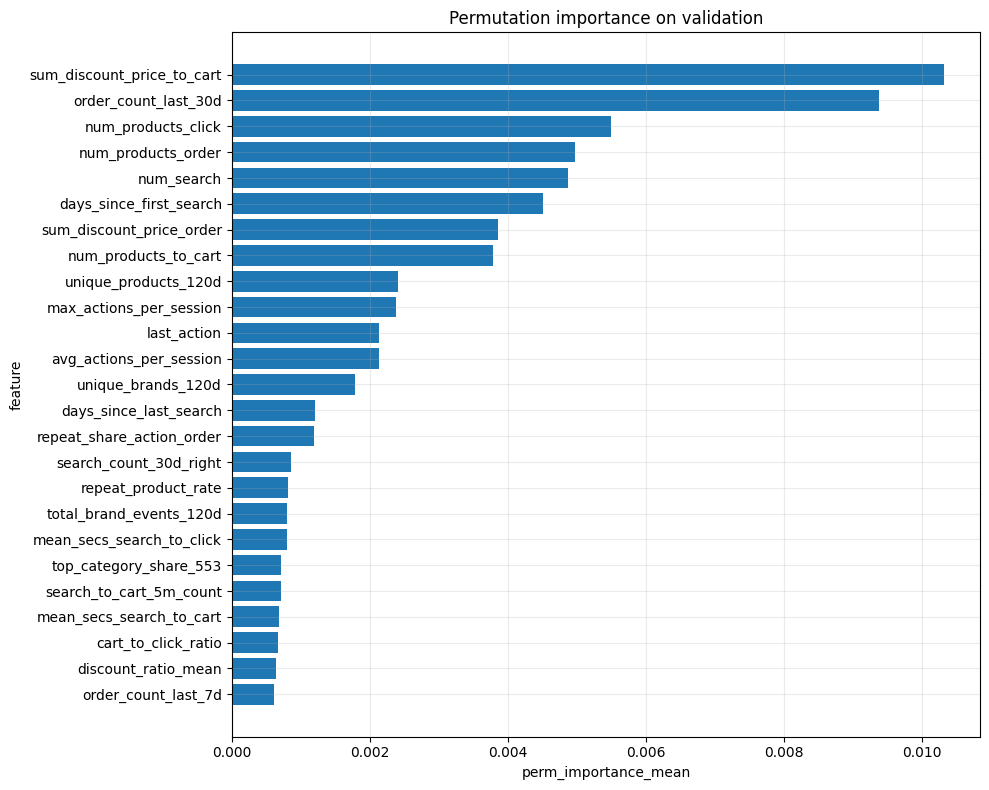

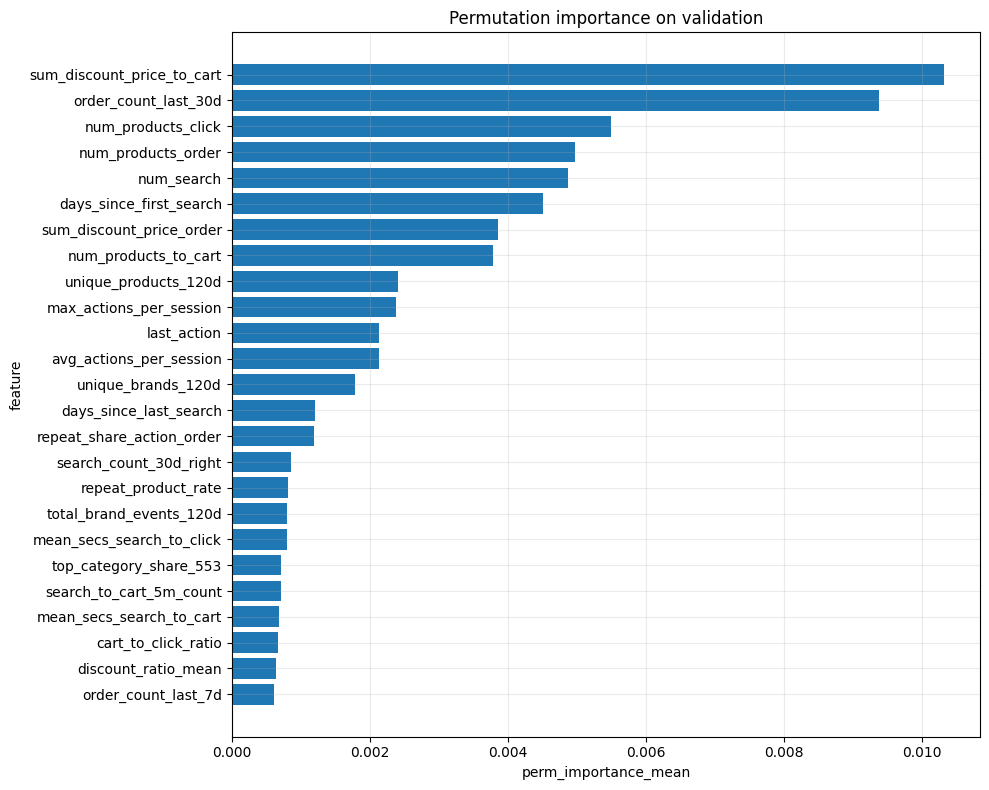

In [ ]:
perm_df = interpreter.get_permutation_importance(
    n_repeats=5,
    scoring="roc_auc",
    refit=False
)
# display(perm_df.head(30))

interpreter.plot_feature_importance_table(
    perm_df,
    value_col="perm_importance_mean",
    title="Permutation importance on validation",
)

In [ ]:
gc.collect()

20284

In [ ]:
ablation_res = interpreter.analyze_feature_ablation(
    features=perm_df["feature"].head(80).tolist()
)
display(ablation_res.table.head(30))

Default metric period is 5 because AUC is/are not implemented for GPU


KeyboardInterrupt: 

In [ ]:
ablation_res.table.to_csv('feature_importance.csv')

In [ ]:
suggestion = interpreter.suggest_features_to_drop(
    corr_threshold=0.995,
    perm_threshold=0.0,
    ablation_min_delta=0.0,
    n_perm_repeats=5,
    max_ablation_features=100,
)

print("constant:", suggestion.constant_features)
print("duplicate:", suggestion.duplicate_features[:10])
print("high corr:", suggestion.high_corr_drop_candidates[:20])
print("low importance:", suggestion.low_importance_features[:20])
print("harmful by ablation:", suggestion.harmful_features_by_ablation[:20])

100%|██████████| 81/81 [17:22<00:00, 12.86s/it]

constant: []
duplicate: []
high corr: []
low importance: ['top_category_share_601_is_nan', 'favorite_brand_share', 'favorite_product_share', 'favorite_category_share', 'top_category_share_483_is_nan', 'top_category_share_236_is_nan', 'top_category_share_224_is_nan', 'top_category_share_404_is_nan', 'top_category_share_413_is_nan', 'top_category_share_829_is_nan', 'top_category_share_623_is_nan', 'max_discount_price_favorite_is_nan', 'last_actions_count_is_capped', 'order_trend_delta_30d_is_nan', 'search_to_cart_30m_count_is_nan', 'days_since_first_favorite_is_nan', 'days_since_first_order_is_nan', 'top_category_share_553_is_nan', 'days_since_first_to_cart_is_nan', 'top_category_share_512_is_nan']
harmful by ablation: ['sum_discount_price_click', 'product_сыр_flag_count_30d', 'mean_secs_search_to_cart_is_nan', 'mean_secs_search_to_click_is_nan', 'search_to_cart_30m_count_is_nan', 'last_3_action', 'search_count_last_7d_is_nan', 'product_хлеб_flag_rate_30d', 'days_since_first_search_is_na

Проверка 1

constant: []

duplicate: [('days_since_last_search', 'days_since_last_search_right'), ('favorite_category_cnt_120d', 'favorite_category_count'), ('favorite_category_share', 'favorite_category_share_120d'), ('search_count_30d_right', 'search_events_30d'), ('total_category_events', 'total_category_events_120d'), ('unique_categories', 'unique_categories_120d'), ('search_count_30d', 'view_count_30d'), ('actions_trend_delta_7d_is_nan', 'actions_trend_ratio_7d_is_nan'), ('avg_query_len_chars_30d_is_nan', 'avg_query_len_words_30d_is_nan'), ('add_to_cart_count_30d_is_nan', 'cart_to_click_ratio_is_nan')]

high corr: ['days_since_last_search_right', 'favorite_category_count', 'product_банан_flag_rate_30d', 'product_батон_flag_rate_30d', 'product_йогурт_flag_rate_30d', 'product_кефир_flag_rate_30d', 'product_колбас_flag_rate_30d', 'product_кофе_flag_rate_30d', 'product_курица_flag_rate_30d', 'product_творог_flag_rate_30d', 'product_чай_flag_rate_30d', 'product_шоколад_flag_rate_30d', 'product_яблок_flag_rate_30d', 'product_яйца_flag_rate_30d', 'queries_with_product_keywords_30d', 'search_events_30d', 'search_to_cart_60m_count', 'search_to_click_60m_count', 'total_category_events', 'total_category_events_120d']

low importance: ['repeat_category_rate_is_nan', 'repeat_categories_120d_is_nan', 'repeat_share_action_click_is_nan', 'product_яблок_flag_rate_30d_is_nan', 'last_query_product_батон', 'fraction_discounted_products', 'product_хлеб_flag_rate_30d_is_nan', 'last_query_product_хлеб', 'product_яйца_flag_rate_30d_is_nan', 'favorite_product_share', 'last_query_product_яблок', 'unique_searches_trend_delta_7d_is_nan', 'favorite_category_share', 'product_шоколад_flag_rate_30d_is_nan', 'product_шоколад_flag_count_30d_is_nan', 'product_чай_flag_rate_30d_is_nan', 'product_чай_flag_count_30d_is_nan', 'top_category_share_829_is_nan', 'total_brand_events_120d_is_nan', 'total_category_events_is_nan']

harmful by ablation: ['total_brand_events_120d_is_nan', 'repeat_brands_120d_is_nan', 'repeat_brand_rate_is_nan', 'view_count_30d_is_capped', 'unique_searches_trend_delta_7d_is_nan', 'product_колбас_flag_rate_30d_is_nan', 'product_кефир_flag_rate_30d_is_nan', 'product_хлеб_flag_rate_30d_is_nan', 'product_шоколад_flag_count_30d_is_nan', 'product_йогурт_flag_rate_30d_is_nan', 'product_шоколад_flag_rate_30d_is_nan', 'product_чай_flag_count_30d_is_nan', 'product_хлеб_flag_count_30d_is_nan', 'product_творог_flag_rate_30d_is_nan', 'product_сыр_flag_rate_30d_is_nan', 'product_творог_flag_count_30d_is_nan', 'product_сыр_flag_count_30d_is_nan', 'product_чай_flag_rate_30d_is_nan', 'product_молоко_flag_count_30d_is_nan', 'product_курица_flag_rate_30d_is_nan']

In [ ]:
import json

with open('drop_1.json', 'wt', encoding='utf-8-sig') as f:
    json.dump(suggestion.__dict__, f) 

### UPD 3

Проверим насколько две модели (lightgbm и catboost) компенсируют недостатки друг друга

In [ ]:
import matplotlib.pyplot as plt

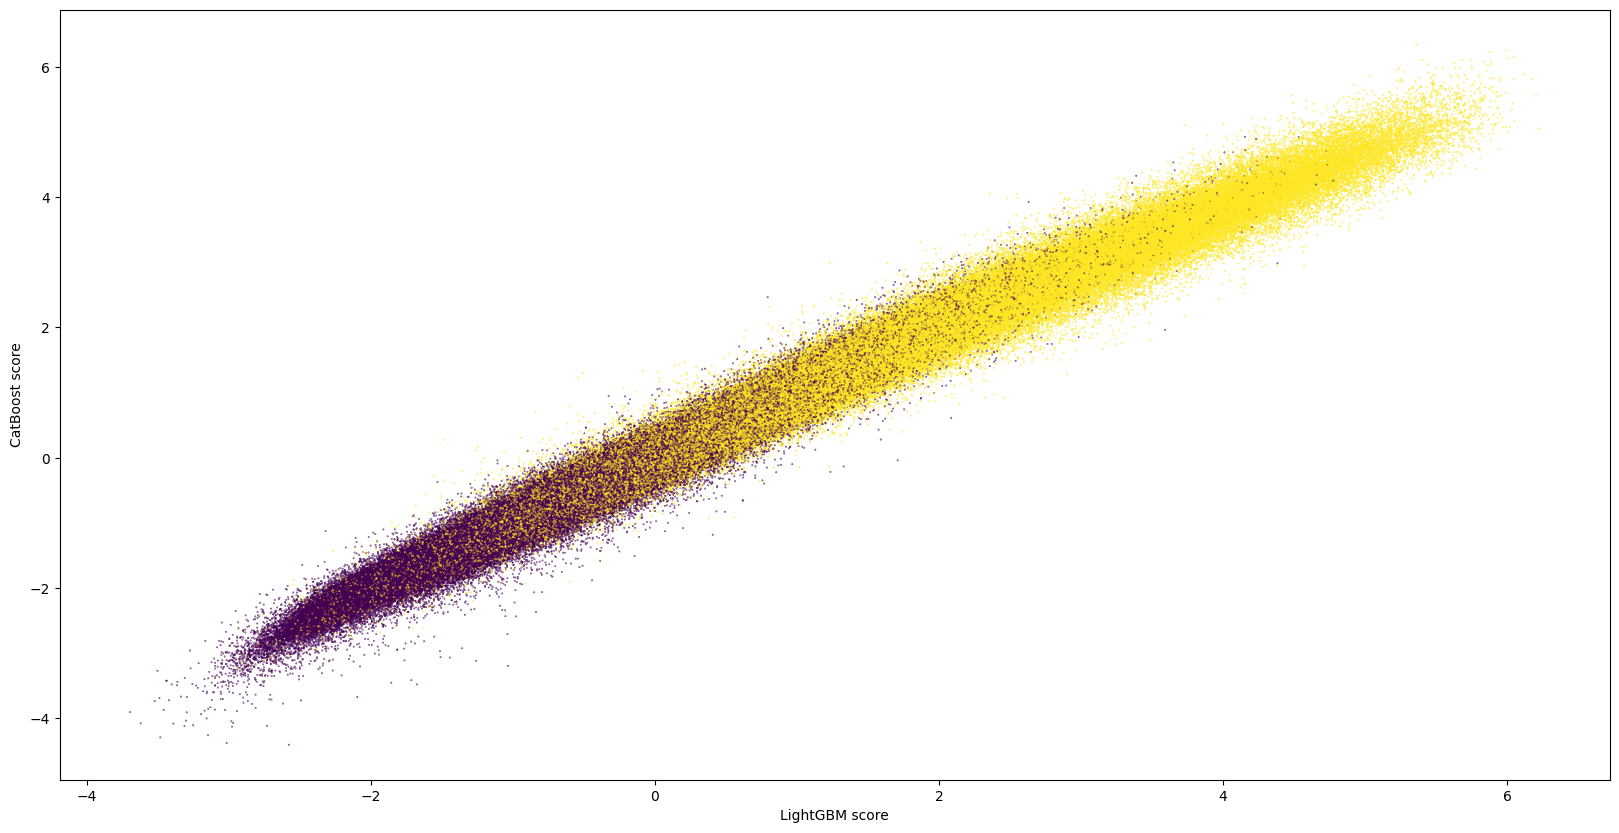

In [ ]:
y_pred_lgb_train = lgb_model.predict(X_train, raw_score=True)
y_pred_cb_train = model.predict(X_train, prediction_type='RawFormulaVal')
plt.figure(figsize=(20, 10))
plt.xlabel('LightGBM score')
plt.ylabel('CatBoost score')
plt.scatter(y_pred_lgb_train, y_pred_cb_train, c=y_train, s=1e-1)

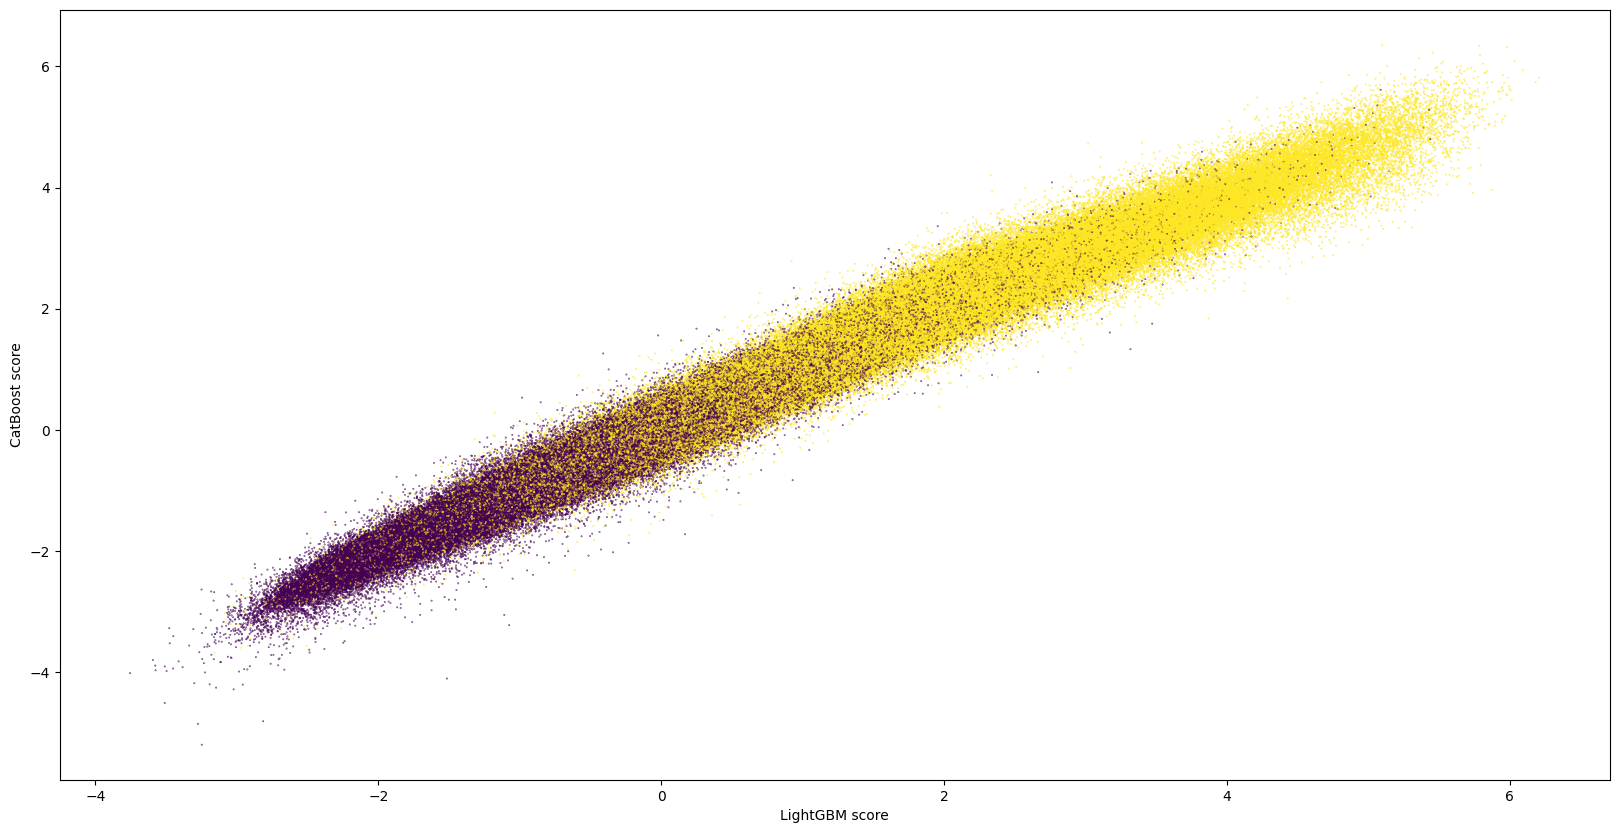

In [ ]:
y_pred_lgb_val = lgb_model.predict(X_val, raw_score=True)
y_pred_cb_val = model.predict(X_val, prediction_type='RawFormulaVal')
plt.figure(figsize=(20, 10))
plt.xlabel('LightGBM score')
plt.ylabel('CatBoost score')
plt.scatter(y_pred_lgb_val, y_pred_cb_val, c=y_val, s=1e-1)

In [ ]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.svm import SVC

In [ ]:
stack_model = Pipeline(
    [
        ('prep', StandardScaler()),
        ('clf', LogisticRegressionCV())
    ]
)

In [ ]:
X_stack_train = np.vstack([y_pred_lgb_train, y_pred_cb_train]).T
X_stack_val = np.vstack([y_pred_lgb_val, y_pred_cb_val]).T

In [ ]:
stack_model.fit(X_stack_train, y_train)

In [ ]:
from sklearn.metrics import roc_auc_score, confusion_matrix

In [ ]:
probs = stack_model.predict_proba(X_stack_val)[:, 1]

In [ ]:
roc_auc_score(y_val, probs)

0.7575878592923794

In [ ]:
confusion_matrix(y_val, stack_model.predict(X_stack_val), normalize='all')

array([[0.58702178, 0.06759679],
       [0.17820632, 0.16717512]])

In [ ]:
confusion_matrix(y_val, np.round(lgb_model.predict(X_val)).astype(int), normalize='all')

array([[0.58776419, 0.06685437],
       [0.17903087, 0.16635057]])

In [ ]:
confusion_matrix(y_val, model.predict(X_val), normalize='all')

array([[0.5866927 , 0.06792586],
       [0.17857059, 0.16681085]])

Вроде логрег на скорах показывает себя чуть хуже чем одна из моделей, но точно можно сказать будет только если всё залить и проверить. Из интересного - мы чаще недооцениваем вероятность того что человек что-то закажет

### UPD
Внизу прикрепил скоры, стэкинг действительно хорошо себя показал

## Тюнинг параметров


Скор - 0.82092

In [29]:
do_tune = True

In [30]:
import optuna
from sklearn.metrics import roc_auc_score

In [31]:
def objective(trial: optuna.Trial):
    eta = trial.suggest_float("eta", 1e-3, 1.0, log=True)
    depth = trial.suggest_int("depth", 5, 10)
    
    params['eta'] = eta
    params['depth'] = depth
        
    model = CatBoostClassifier(**params)

    model.fit(
        train_pool,
        eval_set=val_pool,
        use_best_model=True,
        verbose=False,
        early_stopping_rounds=50,
    )
    
    trial.set_user_attr("iterations", model.tree_count_)

    preds = model.predict_proba(X_val)[:, 1]
    
    score = roc_auc_score(y_val, preds)
    return score

In [32]:
def objective_lgb(trial: optuna.Trial):
    eta = trial.suggest_float("eta", 1e-3, 1.0, log=True)
    depth = trial.suggest_int("max_leaves", 16, 64)

    lgb_params['eta'] = eta
    lgb_params['depth'] = depth

    lgb_model = lgb.train(
        lgb_params,
        train_set=train_dataset,
        valid_sets=[train_dataset, val_dataset],
        valid_names=["train", "valid"],
        num_boost_round=4000,
        callbacks=[
            lgb.early_stopping(stopping_rounds=200),
            lgb.log_evaluation(period=100),
        ],
    )
    trial.set_user_attr("iterations", lgb_model.num_trees())
    
    preds = lgb_model.predict(X_val)
    
    score = roc_auc_score(y_val, preds)
    return score

In [34]:
if do_tune:
    study_lgb = optuna.create_study(direction='maximize', study_name='LightGBM')
    params['iterations'] = 500
    study_lgb.optimize(objective_lgb, n_trials=20)
    
    from optuna.visualization import plot_contour
    from plotly.io import show
    
    fig = plot_contour(study_lgb)

    show(fig)
    
    lgb_best_params = study_lgb.best_params
else:
    lgb_best_params = {}

[I 2026-04-19 14:41:42,389] A new study created in memory with name: LightGBM


Training until validation scores don't improve for 200 rounds
[100]	train's auc: 0.751338	valid's auc: 0.755387
[200]	train's auc: 0.753353	valid's auc: 0.756389
[300]	train's auc: 0.754568	valid's auc: 0.756807
[400]	train's auc: 0.755616	valid's auc: 0.757021
[500]	train's auc: 0.756465	valid's auc: 0.757096
[600]	train's auc: 0.757236	valid's auc: 0.757193
[700]	train's auc: 0.757992	valid's auc: 0.757128
[800]	train's auc: 0.75864	valid's auc: 0.75719
Early stopping, best iteration is:
[624]	train's auc: 0.757464	valid's auc: 0.757236


[I 2026-04-19 14:43:36,392] Trial 0 finished with value: 0.7572356423264623 and parameters: {'eta': 0.0015944431239475279, 'max_leaves': 36}. Best is trial 0 with value: 0.7572356423264623.


Training until validation scores don't improve for 200 rounds
[100]	train's auc: 0.751338	valid's auc: 0.755387
[200]	train's auc: 0.753353	valid's auc: 0.756389
[300]	train's auc: 0.754568	valid's auc: 0.756807
[400]	train's auc: 0.755616	valid's auc: 0.757021
[500]	train's auc: 0.756465	valid's auc: 0.757096
[600]	train's auc: 0.757236	valid's auc: 0.757193
[700]	train's auc: 0.757992	valid's auc: 0.757128
[800]	train's auc: 0.75864	valid's auc: 0.75719
Early stopping, best iteration is:
[624]	train's auc: 0.757464	valid's auc: 0.757236


[I 2026-04-19 14:45:31,799] Trial 1 finished with value: 0.7572356423264623 and parameters: {'eta': 0.04932285994150135, 'max_leaves': 50}. Best is trial 0 with value: 0.7572356423264623.


Training until validation scores don't improve for 200 rounds
[100]	train's auc: 0.751338	valid's auc: 0.755387
[200]	train's auc: 0.753353	valid's auc: 0.756389
[300]	train's auc: 0.754568	valid's auc: 0.756807
[400]	train's auc: 0.755616	valid's auc: 0.757021
[500]	train's auc: 0.756465	valid's auc: 0.757096
[600]	train's auc: 0.757236	valid's auc: 0.757193
[700]	train's auc: 0.757992	valid's auc: 0.757128
[800]	train's auc: 0.75864	valid's auc: 0.75719
Early stopping, best iteration is:
[624]	train's auc: 0.757464	valid's auc: 0.757236


[I 2026-04-19 14:47:18,306] Trial 2 finished with value: 0.7572356423264623 and parameters: {'eta': 0.010291692729064501, 'max_leaves': 48}. Best is trial 0 with value: 0.7572356423264623.


Training until validation scores don't improve for 200 rounds
[100]	train's auc: 0.751338	valid's auc: 0.755387
[200]	train's auc: 0.753353	valid's auc: 0.756389
[300]	train's auc: 0.754568	valid's auc: 0.756807
[400]	train's auc: 0.755616	valid's auc: 0.757021
[500]	train's auc: 0.756465	valid's auc: 0.757096
[600]	train's auc: 0.757236	valid's auc: 0.757193
[700]	train's auc: 0.757992	valid's auc: 0.757128
[800]	train's auc: 0.75864	valid's auc: 0.75719
Early stopping, best iteration is:
[624]	train's auc: 0.757464	valid's auc: 0.757236


[I 2026-04-19 14:49:00,466] Trial 3 finished with value: 0.7572356423264623 and parameters: {'eta': 0.07875402785255055, 'max_leaves': 17}. Best is trial 0 with value: 0.7572356423264623.


Training until validation scores don't improve for 200 rounds
[100]	train's auc: 0.751338	valid's auc: 0.755387
[200]	train's auc: 0.753353	valid's auc: 0.756389
[300]	train's auc: 0.754568	valid's auc: 0.756807
[400]	train's auc: 0.755616	valid's auc: 0.757021
[500]	train's auc: 0.756465	valid's auc: 0.757096
[600]	train's auc: 0.757236	valid's auc: 0.757193
[700]	train's auc: 0.757992	valid's auc: 0.757128
[800]	train's auc: 0.75864	valid's auc: 0.75719
Early stopping, best iteration is:
[624]	train's auc: 0.757464	valid's auc: 0.757236


[I 2026-04-19 14:50:42,872] Trial 4 finished with value: 0.7572356423264623 and parameters: {'eta': 0.1390072551165602, 'max_leaves': 45}. Best is trial 0 with value: 0.7572356423264623.


Training until validation scores don't improve for 200 rounds
[100]	train's auc: 0.751338	valid's auc: 0.755387
[200]	train's auc: 0.753353	valid's auc: 0.756389
[300]	train's auc: 0.754568	valid's auc: 0.756807
[400]	train's auc: 0.755616	valid's auc: 0.757021
[500]	train's auc: 0.756465	valid's auc: 0.757096
[600]	train's auc: 0.757236	valid's auc: 0.757193
[700]	train's auc: 0.757992	valid's auc: 0.757128
[800]	train's auc: 0.75864	valid's auc: 0.75719
Early stopping, best iteration is:
[624]	train's auc: 0.757464	valid's auc: 0.757236


[I 2026-04-19 14:52:27,490] Trial 5 finished with value: 0.7572356423264623 and parameters: {'eta': 0.03376774685971943, 'max_leaves': 25}. Best is trial 0 with value: 0.7572356423264623.


Training until validation scores don't improve for 200 rounds
[100]	train's auc: 0.751338	valid's auc: 0.755387
[200]	train's auc: 0.753353	valid's auc: 0.756389
[300]	train's auc: 0.754568	valid's auc: 0.756807
[400]	train's auc: 0.755616	valid's auc: 0.757021
[500]	train's auc: 0.756465	valid's auc: 0.757096
[600]	train's auc: 0.757236	valid's auc: 0.757193
[700]	train's auc: 0.757992	valid's auc: 0.757128
[800]	train's auc: 0.75864	valid's auc: 0.75719
Early stopping, best iteration is:
[624]	train's auc: 0.757464	valid's auc: 0.757236


[I 2026-04-19 14:54:10,534] Trial 6 finished with value: 0.7572356423264623 and parameters: {'eta': 0.13123334630553646, 'max_leaves': 36}. Best is trial 0 with value: 0.7572356423264623.


Training until validation scores don't improve for 200 rounds
[100]	train's auc: 0.751338	valid's auc: 0.755387
[200]	train's auc: 0.753353	valid's auc: 0.756389
[300]	train's auc: 0.754568	valid's auc: 0.756807
[400]	train's auc: 0.755616	valid's auc: 0.757021
[500]	train's auc: 0.756465	valid's auc: 0.757096
[600]	train's auc: 0.757236	valid's auc: 0.757193
[700]	train's auc: 0.757992	valid's auc: 0.757128
[800]	train's auc: 0.75864	valid's auc: 0.75719
Early stopping, best iteration is:
[624]	train's auc: 0.757464	valid's auc: 0.757236


[I 2026-04-19 14:55:53,743] Trial 7 finished with value: 0.7572356423264623 and parameters: {'eta': 0.07545151884323084, 'max_leaves': 20}. Best is trial 0 with value: 0.7572356423264623.


Training until validation scores don't improve for 200 rounds
[100]	train's auc: 0.751338	valid's auc: 0.755387
[200]	train's auc: 0.753353	valid's auc: 0.756389
[300]	train's auc: 0.754568	valid's auc: 0.756807
[400]	train's auc: 0.755616	valid's auc: 0.757021
[500]	train's auc: 0.756465	valid's auc: 0.757096
[600]	train's auc: 0.757236	valid's auc: 0.757193
[700]	train's auc: 0.757992	valid's auc: 0.757128
[800]	train's auc: 0.75864	valid's auc: 0.75719
Early stopping, best iteration is:
[624]	train's auc: 0.757464	valid's auc: 0.757236


[I 2026-04-19 14:57:37,042] Trial 8 finished with value: 0.7572356423264623 and parameters: {'eta': 0.05463646745616261, 'max_leaves': 62}. Best is trial 0 with value: 0.7572356423264623.


Training until validation scores don't improve for 200 rounds
[100]	train's auc: 0.751338	valid's auc: 0.755387
[200]	train's auc: 0.753353	valid's auc: 0.756389
[300]	train's auc: 0.754568	valid's auc: 0.756807
[400]	train's auc: 0.755616	valid's auc: 0.757021
[500]	train's auc: 0.756465	valid's auc: 0.757096
[600]	train's auc: 0.757236	valid's auc: 0.757193
[700]	train's auc: 0.757992	valid's auc: 0.757128
[800]	train's auc: 0.75864	valid's auc: 0.75719
Early stopping, best iteration is:
[624]	train's auc: 0.757464	valid's auc: 0.757236


[I 2026-04-19 14:59:19,561] Trial 9 finished with value: 0.7572356423264623 and parameters: {'eta': 0.17116157655961628, 'max_leaves': 20}. Best is trial 0 with value: 0.7572356423264623.


Training until validation scores don't improve for 200 rounds
[100]	train's auc: 0.751338	valid's auc: 0.755387
[200]	train's auc: 0.753353	valid's auc: 0.756389
[300]	train's auc: 0.754568	valid's auc: 0.756807
[400]	train's auc: 0.755616	valid's auc: 0.757021
[500]	train's auc: 0.756465	valid's auc: 0.757096
[600]	train's auc: 0.757236	valid's auc: 0.757193
[700]	train's auc: 0.757992	valid's auc: 0.757128
[800]	train's auc: 0.75864	valid's auc: 0.75719
Early stopping, best iteration is:
[624]	train's auc: 0.757464	valid's auc: 0.757236


[I 2026-04-19 15:01:02,020] Trial 10 finished with value: 0.7572356423264623 and parameters: {'eta': 0.001374191100882906, 'max_leaves': 34}. Best is trial 0 with value: 0.7572356423264623.


Training until validation scores don't improve for 200 rounds
[100]	train's auc: 0.751338	valid's auc: 0.755387
[200]	train's auc: 0.753353	valid's auc: 0.756389
[300]	train's auc: 0.754568	valid's auc: 0.756807
[400]	train's auc: 0.755616	valid's auc: 0.757021
[500]	train's auc: 0.756465	valid's auc: 0.757096
[600]	train's auc: 0.757236	valid's auc: 0.757193
[700]	train's auc: 0.757992	valid's auc: 0.757128
[800]	train's auc: 0.75864	valid's auc: 0.75719
Early stopping, best iteration is:
[624]	train's auc: 0.757464	valid's auc: 0.757236


[I 2026-04-19 15:02:44,630] Trial 11 finished with value: 0.7572356423264623 and parameters: {'eta': 0.6686032948467049, 'max_leaves': 55}. Best is trial 0 with value: 0.7572356423264623.


Training until validation scores don't improve for 200 rounds
[100]	train's auc: 0.751338	valid's auc: 0.755387
[200]	train's auc: 0.753353	valid's auc: 0.756389
[300]	train's auc: 0.754568	valid's auc: 0.756807
[400]	train's auc: 0.755616	valid's auc: 0.757021
[500]	train's auc: 0.756465	valid's auc: 0.757096
[600]	train's auc: 0.757236	valid's auc: 0.757193
[700]	train's auc: 0.757992	valid's auc: 0.757128
[800]	train's auc: 0.75864	valid's auc: 0.75719
Early stopping, best iteration is:
[624]	train's auc: 0.757464	valid's auc: 0.757236


[I 2026-04-19 15:04:25,868] Trial 12 finished with value: 0.7572356423264623 and parameters: {'eta': 0.006786888364302942, 'max_leaves': 42}. Best is trial 0 with value: 0.7572356423264623.


Training until validation scores don't improve for 200 rounds
[100]	train's auc: 0.751338	valid's auc: 0.755387
[200]	train's auc: 0.753353	valid's auc: 0.756389
[300]	train's auc: 0.754568	valid's auc: 0.756807
[400]	train's auc: 0.755616	valid's auc: 0.757021
[500]	train's auc: 0.756465	valid's auc: 0.757096
[600]	train's auc: 0.757236	valid's auc: 0.757193
[700]	train's auc: 0.757992	valid's auc: 0.757128
[800]	train's auc: 0.75864	valid's auc: 0.75719
Early stopping, best iteration is:
[624]	train's auc: 0.757464	valid's auc: 0.757236


[I 2026-04-19 15:06:08,928] Trial 13 finished with value: 0.7572356423264623 and parameters: {'eta': 0.0010485781524712675, 'max_leaves': 52}. Best is trial 0 with value: 0.7572356423264623.


Training until validation scores don't improve for 200 rounds
[100]	train's auc: 0.751338	valid's auc: 0.755387
[200]	train's auc: 0.753353	valid's auc: 0.756389
[300]	train's auc: 0.754568	valid's auc: 0.756807
[400]	train's auc: 0.755616	valid's auc: 0.757021
[500]	train's auc: 0.756465	valid's auc: 0.757096
[600]	train's auc: 0.757236	valid's auc: 0.757193
[700]	train's auc: 0.757992	valid's auc: 0.757128
[800]	train's auc: 0.75864	valid's auc: 0.75719
Early stopping, best iteration is:
[624]	train's auc: 0.757464	valid's auc: 0.757236


[I 2026-04-19 15:07:51,961] Trial 14 finished with value: 0.7572356423264623 and parameters: {'eta': 0.007180865062667035, 'max_leaves': 36}. Best is trial 0 with value: 0.7572356423264623.


Training until validation scores don't improve for 200 rounds
[100]	train's auc: 0.751338	valid's auc: 0.755387
[200]	train's auc: 0.753353	valid's auc: 0.756389
[300]	train's auc: 0.754568	valid's auc: 0.756807
[400]	train's auc: 0.755616	valid's auc: 0.757021
[500]	train's auc: 0.756465	valid's auc: 0.757096
[600]	train's auc: 0.757236	valid's auc: 0.757193
[700]	train's auc: 0.757992	valid's auc: 0.757128
[800]	train's auc: 0.75864	valid's auc: 0.75719
Early stopping, best iteration is:
[624]	train's auc: 0.757464	valid's auc: 0.757236


[I 2026-04-19 15:09:34,954] Trial 15 finished with value: 0.7572356423264623 and parameters: {'eta': 0.003039040421858899, 'max_leaves': 29}. Best is trial 0 with value: 0.7572356423264623.


Training until validation scores don't improve for 200 rounds
[100]	train's auc: 0.751338	valid's auc: 0.755387
[200]	train's auc: 0.753353	valid's auc: 0.756389
[300]	train's auc: 0.754568	valid's auc: 0.756807
[400]	train's auc: 0.755616	valid's auc: 0.757021
[500]	train's auc: 0.756465	valid's auc: 0.757096
[600]	train's auc: 0.757236	valid's auc: 0.757193
[700]	train's auc: 0.757992	valid's auc: 0.757128
[800]	train's auc: 0.75864	valid's auc: 0.75719
Early stopping, best iteration is:
[624]	train's auc: 0.757464	valid's auc: 0.757236


[I 2026-04-19 15:11:18,369] Trial 16 finished with value: 0.7572356423264623 and parameters: {'eta': 0.018325226361445925, 'max_leaves': 61}. Best is trial 0 with value: 0.7572356423264623.


Training until validation scores don't improve for 200 rounds
[100]	train's auc: 0.751338	valid's auc: 0.755387
[200]	train's auc: 0.753353	valid's auc: 0.756389
[300]	train's auc: 0.754568	valid's auc: 0.756807
[400]	train's auc: 0.755616	valid's auc: 0.757021
[500]	train's auc: 0.756465	valid's auc: 0.757096
[600]	train's auc: 0.757236	valid's auc: 0.757193
[700]	train's auc: 0.757992	valid's auc: 0.757128
[800]	train's auc: 0.75864	valid's auc: 0.75719
Early stopping, best iteration is:
[624]	train's auc: 0.757464	valid's auc: 0.757236


[I 2026-04-19 15:13:01,217] Trial 17 finished with value: 0.7572356423264623 and parameters: {'eta': 0.37369216210699197, 'max_leaves': 54}. Best is trial 0 with value: 0.7572356423264623.


Training until validation scores don't improve for 200 rounds
[100]	train's auc: 0.751338	valid's auc: 0.755387
[200]	train's auc: 0.753353	valid's auc: 0.756389
[300]	train's auc: 0.754568	valid's auc: 0.756807
[400]	train's auc: 0.755616	valid's auc: 0.757021
[500]	train's auc: 0.756465	valid's auc: 0.757096
[600]	train's auc: 0.757236	valid's auc: 0.757193
[700]	train's auc: 0.757992	valid's auc: 0.757128
[800]	train's auc: 0.75864	valid's auc: 0.75719
Early stopping, best iteration is:
[624]	train's auc: 0.757464	valid's auc: 0.757236


[I 2026-04-19 15:14:43,224] Trial 18 finished with value: 0.7572356423264623 and parameters: {'eta': 0.0032741805469161645, 'max_leaves': 30}. Best is trial 0 with value: 0.7572356423264623.


Training until validation scores don't improve for 200 rounds
[100]	train's auc: 0.751338	valid's auc: 0.755387
[200]	train's auc: 0.753353	valid's auc: 0.756389
[300]	train's auc: 0.754568	valid's auc: 0.756807
[400]	train's auc: 0.755616	valid's auc: 0.757021
[500]	train's auc: 0.756465	valid's auc: 0.757096
[600]	train's auc: 0.757236	valid's auc: 0.757193
[700]	train's auc: 0.757992	valid's auc: 0.757128
[800]	train's auc: 0.75864	valid's auc: 0.75719
Early stopping, best iteration is:
[624]	train's auc: 0.757464	valid's auc: 0.757236


[I 2026-04-19 15:16:26,840] Trial 19 finished with value: 0.7572356423264623 and parameters: {'eta': 0.018840322725784144, 'max_leaves': 41}. Best is trial 0 with value: 0.7572356423264623.


In [35]:
if do_tune:
    study_cb = optuna.create_study(direction='maximize', study_name='CatBoost')
    params['iterations'] = 500
    study_cb.optimize(objective, n_trials=100)
    
    from optuna.visualization import plot_contour
    from plotly.io import show
    
    fig = plot_contour(study_cb)

    show(fig)
    
    best_params = study_cb.best_params
else:
    best_params = {'eta': 0.055848570897405615, 'depth': 8}

[I 2026-04-19 15:16:26,945] A new study created in memory with name: CatBoost
Default metric period is 5 because AUC is/are not implemented for GPU
[I 2026-04-19 15:16:52,193] Trial 0 finished with value: 0.7519217767022259 and parameters: {'eta': 0.0019153114459841277, 'depth': 6}. Best is trial 0 with value: 0.7519217767022259.
Default metric period is 5 because AUC is/are not implemented for GPU
[I 2026-04-19 15:17:04,891] Trial 1 finished with value: 0.7560149699373084 and parameters: {'eta': 0.27265408002479147, 'depth': 10}. Best is trial 1 with value: 0.7560149699373084.
Default metric period is 5 because AUC is/are not implemented for GPU
[I 2026-04-19 15:17:34,161] Trial 2 finished with value: 0.7547142875969687 and parameters: {'eta': 0.008246079993029436, 'depth': 7}. Best is trial 1 with value: 0.7560149699373084.
Default metric period is 5 because AUC is/are not implemented for GPU
[I 2026-04-19 15:17:42,623] Trial 3 finished with value: 0.7553994039376094 and parameters: 

In [41]:
iterations_cb = study_cb.best_trial.user_attrs['iterations']

In [40]:
iterations_lgb = study_lgb.best_trial.user_attrs['iterations']

In [44]:
best_params = study_cb.best_params

In [45]:
params.update(best_params)
params['iterations'] = iterations_cb

In [46]:
best_params_lgb = study_lgb.best_params

In [47]:
lgb_params.update(best_params_lgb)

In [50]:
del lgb_params['max_leaves']

## Финальное предсказание

In [51]:
X_train_val = pd.concat([X_train, X_val], axis=0)

In [53]:
y_train_val = pd.concat([y_train, y_val], axis=0)

In [54]:
params

{'iterations': 500,
 'depth': 7,
 'random_state': 1,
 'eval_metric': 'AUC',
 'loss_function': 'Logloss',
 'auto_class_weights': 'Balanced',
 'task_type': 'GPU',
 'cat_features': ['last_2_action',
  'last_3_action',
  'last_3_actions_str',
  'last_action'],
 'embedding_features': None,
 'devices': '0',
 'eta': 0.0826197051068673}

In [57]:
model = CatBoostClassifier(**params)

model.fit(
        X_train_val, y_train_val,
        eval_set=val_pool,
        use_best_model=True,
        verbose=10,
        early_stopping_rounds=50,
    )
model.save_model(model_name)

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7462719	best: 0.7462719 (0)	total: 128ms	remaining: 1m 3s
10:	test: 0.7540560	best: 0.7540560 (10)	total: 1.43s	remaining: 1m 3s
20:	test: 0.7553006	best: 0.7553006 (20)	total: 2.71s	remaining: 1m 1s
30:	test: 0.7560830	best: 0.7560830 (30)	total: 4.06s	remaining: 1m 1s
40:	test: 0.7567218	best: 0.7567218 (40)	total: 5.42s	remaining: 1m
50:	test: 0.7572838	best: 0.7572838 (50)	total: 6.75s	remaining: 59.5s
60:	test: 0.7577516	best: 0.7577516 (60)	total: 8.08s	remaining: 58.1s
70:	test: 0.7581543	best: 0.7581543 (70)	total: 9.38s	remaining: 56.7s
80:	test: 0.7585220	best: 0.7585220 (80)	total: 10.7s	remaining: 55.4s
90:	test: 0.7588414	best: 0.7588414 (90)	total: 12s	remaining: 53.9s
100:	test: 0.7591328	best: 0.7591328 (100)	total: 13.3s	remaining: 52.5s
110:	test: 0.7593526	best: 0.7593526 (110)	total: 14.6s	remaining: 51.1s
120:	test: 0.7595682	best: 0.7595682 (120)	total: 15.9s	remaining: 49.9s
130:	test: 0.7597230	best: 0.7597400 (129)	total: 17.2s	remaining: 48.5s
140:	

In [59]:
lgb_model = lgb.train(
    params=lgb_params,
    train_set=lgb.Dataset(X_train_val, label=y_train_val),
    num_boost_round=iterations_lgb
)

In [60]:
if do_construct:
    test_df = former.construct_dataset(
        feature_end_date=date(2024, 7, 31),
        users_df=former.test_users_submission,
        **data_params
    )
    test_df.to_parquet('data/test.parquet', index=False, engine='fastparquet')
else:
    test_df = pd.read_parquet('data/test.parquet', engine='fastparquet')

In [61]:
X_test = test_df.drop(columns='user_id')

In [62]:
X_test = standardizer.transform(X_test)

/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:2054: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_out[f"{col}_is_nan"] = np.isnan(x).astype(float)
/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:2054: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_out[f"{col}_is_nan"] = np.isnan(x).astype(float)
/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:2054: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at on

In [63]:
predict = model.predict(X_test, prediction_type='Probability')

test_df['predict'] = predict[:, 1]
test_df[['user_id', 'predict']].to_csv('overfitted_ahh.csv', index=False)

In [64]:
predict_lgb = lgb_model.predict(X_test)

test_df['predict'] = predict_lgb
test_df[['user_id', 'predict']].to_csv('overfitted_ahh_lgb.csv', index=False)

### UPD хз сколько там

Оба решения дали примерно одинаковый скор, вот он

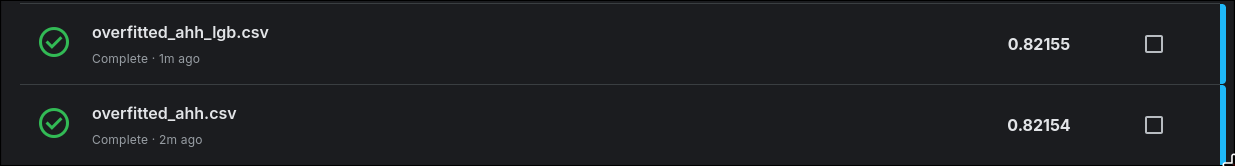

Я ещё попробую фокус со стэкингом логрега на бустингах, посмотрим что получится. Я здесь не использую мета-модель из `sklearn` потому что у катбуста нет нормальной функции возвращающей скор которая подходила бы по интерфейсу, а класс-обёртку мне писать ну очень лень. 

In [65]:
from sklearn.linear_model import LogisticRegressionCV

In [68]:
score_cb_train = model.predict(X_train_val, prediction_type='RawFormulaVal')
score_lgb_train = lgb_model.predict(X_train_val, raw_score=True)

X_train_stack = np.vstack([score_cb_train, score_lgb_train]).T

In [75]:
score_cb_test = model.predict(X_test, prediction_type='RawFormulaVal')
score_lgb_test = lgb_model.predict(X_test, raw_score=True)

X_test_stack = np.vstack([score_cb_test, score_lgb_test]).T

### UPD
Логрег - 0.82167

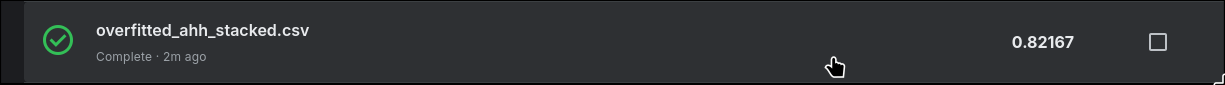

SVM - не успел обучиться

LightGBM с дефолтными гиперпараметрами - 0.82088

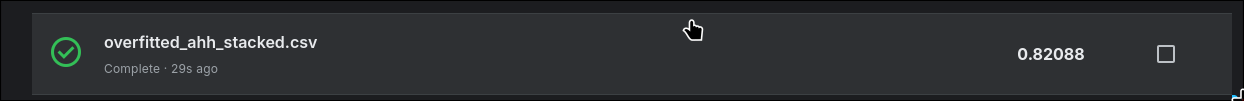

In [ ]:
stack_model = LogisticRegressionCV().fit(X_train_stack, y_train_val)

In [76]:
stack_probs = stack_model.predict_proba(X_test_stack)[:, 1]

/home/i3alumba/Projects/AI/aim_ml/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [77]:
test_df['predict'] = stack_probs
test_df[['user_id', 'predict']].to_csv('overfitted_ahh_stacked.csv', index=False)